# News Feeds — Spatiotemporal Early-Warning Signals

This notebook demonstrates the **news-feed aggregator** (`epidatasets.newsfeeds`),
which fetches open public-health news feeds (WHO, WHO Disease Outbreak News,
PAHO, Eurosurveillance, CDC, CIDRAP, Outbreak News Today and Google News topic
searches), normalizes, deduplicates and disease-tags the items, geo-tags
location mentions and visualizes them in space and time.

Outbreak news often precedes official case data — this is a narrative
early-warning complement to the numeric accessors in this package.

Requires the extras: `pip install "epidatasets[news,geo]"`.

## 1. Fetch and aggregate

In [1]:
from epidatasets.newsfeeds import NewsAggregator

agg = NewsAggregator()          # feeds cached on disk, TTL 6h
items = agg.fetch(days=30)      # concurrent, polite, cached
print(len(items), "items fetched")
items.head()

85 items fetched


,source,title,url,published_utc,summary,language,disease_tags,feed_url
0,paho,UNGA: PAHO joins global efforts to advance pan...,https://www.paho.org/en/news/16-9-2026-unga-pa...,2026-09-16 13:03:21,UNGA: PAHO joins global efforts to advance pan...,en,,https://www.paho.org/en/rss.xml
1,google_news,"DRC Ebola outbreak 'growing exponentially,' UN...",https://news.google.com/rss/articles/CBMia0FVX...,2026-09-15 23:55:46,"DRC Ebola outbreak 'growing exponentially,' UN...",en,ebola,https://news.google.com/rss/search?q=%28dengue...
2,google_news,Fourth person dies of measles-associated illne...,https://news.google.com/rss/articles/CBMiiwFBV...,2026-09-15 18:42:00,Fourth person dies of measles-associated illne...,en,measles,https://news.google.com/rss/search?q=%28dengue...
3,who_afro,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,https://www.afro.who.int/countries/democratic-...,2026-09-15 15:26:56,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,en,ebola,https://www.afro.who.int/rss.xml
4,google_news,Ebola disease outbreak 2026: How MSF is respon...,https://news.google.com/rss/articles/CBMilgFBV...,2026-09-15 15:24:23,Ebola disease outbreak 2026: How MSF is respon...,en,ebola,https://news.google.com/rss/search?q=%28dengue...


In [2]:
# per-source status: one dead feed never blocks the others
import pandas as pd

pd.DataFrame(agg.last_fetch_status).T

,items,error,cached
who_news,25,None,True
who_don,50,None,True
who_afro,10,None,True
paho,10,None,True
eurosurveillance,10,None,True
cidrap,10,None,True
outbreak_news_today,10,None,True
cdc_newsroom,50,None,True
google_news,50,None,True


## 2. Disease tagging

~30 diseases are matched by keyword over title + summary.

In [3]:
tags = items["disease_tags"].str.split("|").explode().value_counts()
tags.head(12)

disease_tags
ebola              29
                   22
measles            13
mpox                6
influenza           6
covid19             4
rabies              3
zika                3
hiv                 1
polio               1
marburg             1
avian_influenza     1
Name: count, dtype: int64

## 3. Geo-tagging location mentions

In [4]:
locations = agg.geotag(items)
covered = locations["url"].nunique() / items["url"].nunique()
print(f"{locations['url'].nunique()}/{items['url'].nunique()} items "
      f"({covered:.0%}) mention at least one known location")
locations[["title", "location_name", "location_type", "iso3"]].head(8)

49/85 items (58%) mention at least one known location


,title,location_name,location_type,iso3
0,"DRC Ebola outbreak 'growing exponentially,' UN...",Democratic Republic of the Congo,country,COD
1,"DRC Ebola outbreak 'growing exponentially,' UN...",Democratic Republic of the Congo,country,COD
2,Fourth person dies of measles-associated illne...,United States,country,USA
3,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,Democratic Republic of the Congo,country,COD
4,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,Democratic Republic of the Congo,country,COD
5,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,Democratic Republic of the Congo,country,COD
6,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,Central African Republic,country,CAF
7,EBOLA BUNDIBUGYO VIRUS DISEASE OUTBREAK Democr...,Republic of the Congo,country,COG


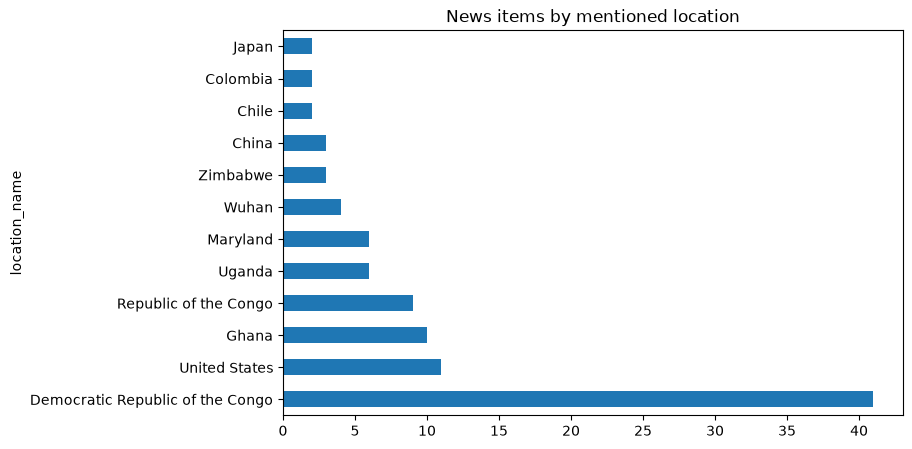

In [5]:
locations["location_name"].value_counts().head(12).plot(
    kind="barh", figsize=(8, 5), title="News items by mentioned location");

## 4. Timeline of item counts

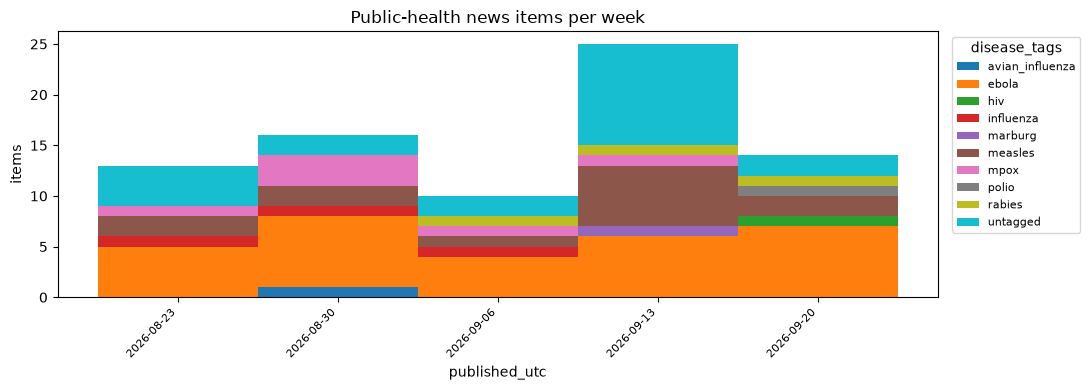

In [6]:
agg.plot_timeline(items, by="disease_tags", freq="W", out="news_timeline.png");

## 5. Interactive map

Each mentioned location becomes a point (size proportional to item count,
popup with the headlines).

In [7]:
fmap = agg.plot_map(locations, out="news_map.html")
fmap

## 6. Animated cumulative spread

Weekly cumulative frames rendered to GIF (first call downloads and caches
the Natural Earth country outlines).

In [8]:
agg.animate_map(locations, out="news_map.gif", freq="W")

'news_map.gif'

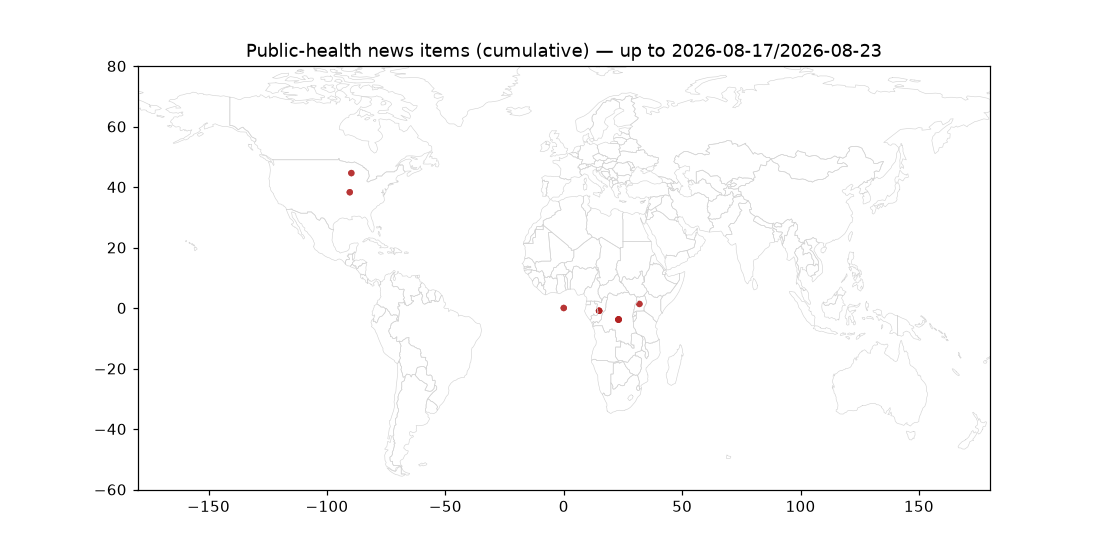

In [9]:
from IPython.display import Image

Image("news_map.gif")